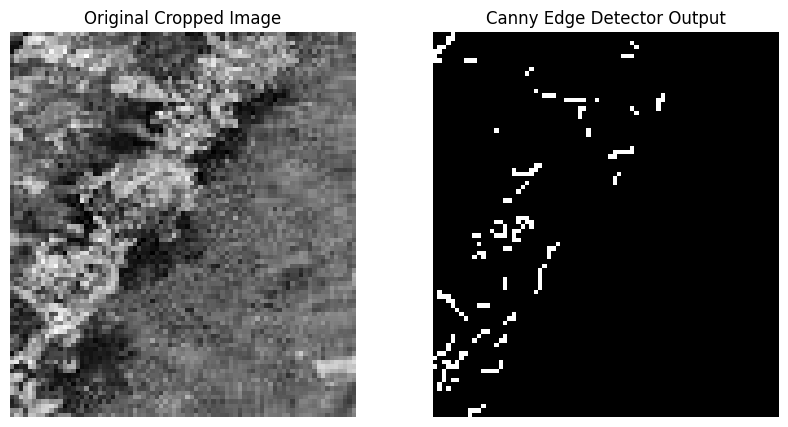

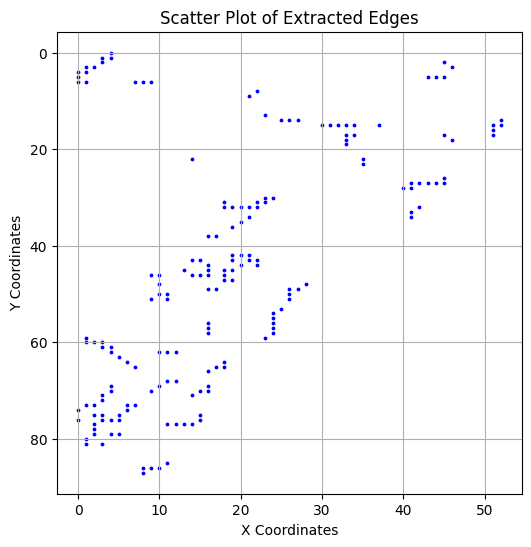

Estimated crop field angle (Least-Squares): -43.39 degrees


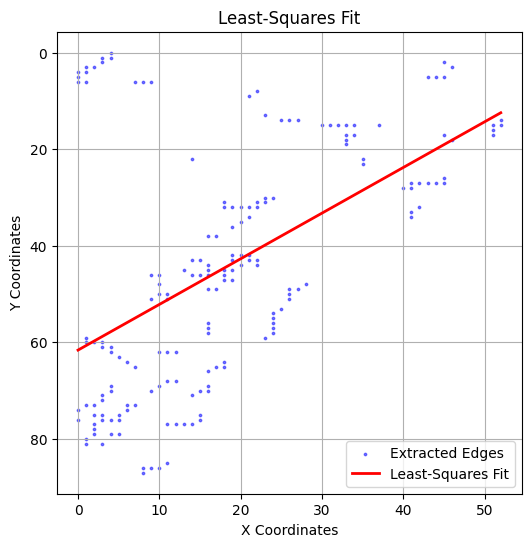

Estimated crop field angle (Total Least-Squares): -69.99 degrees


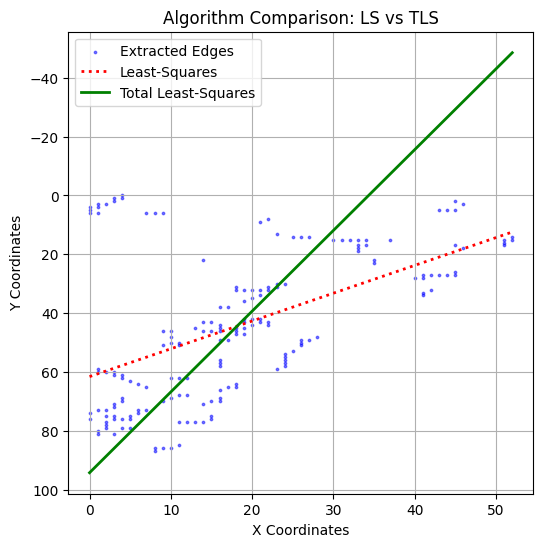

Estimated crop field angle (RANSAC): -51.68 degrees


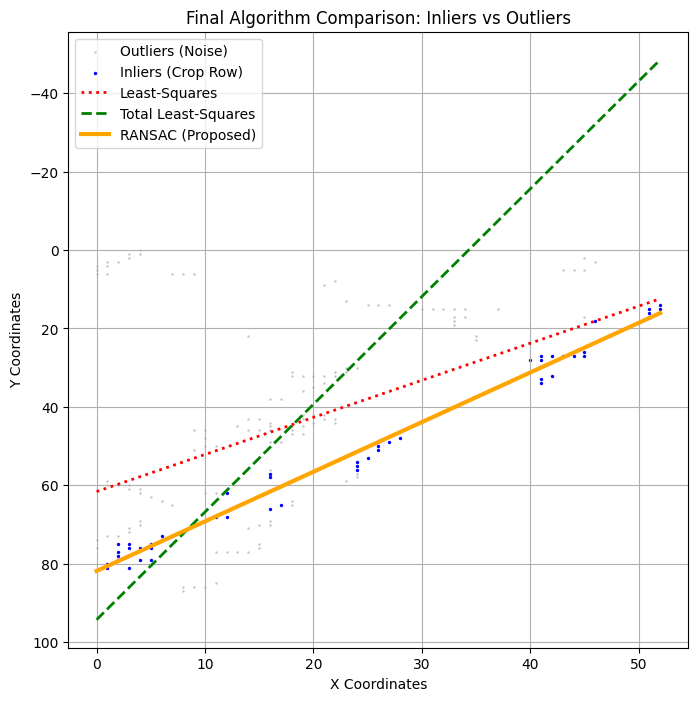

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import RANSACRegressor

img = cv.imread('../Images/img3.jpg', 0)

assert img is not None, "Error: Could not load image. Check path."

# Question 1
# Apply the Canny edge detector
edges = cv.Canny(img, 550, 690)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Cropped Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detector Output')
plt.axis('off')

plt.show()

# Question 2
# Extract coordinates using NumPy
indices = np.where(edges != 0)

x = indices[1]
y = indices[0]

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=3, color='blue')
plt.gca().invert_yaxis()

plt.title('Scatter Plot of Extracted Edges')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.grid(True)

plt.show()

# Question 3
N = len(x)

sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x**2)

m_ls = (N * sum_xy - sum_x * sum_y) / (N * sum_x2 - sum_x**2)
c_ls = (sum_y - m_ls * sum_x) / N

x_line = np.array([np.min(x), np.max(x)])
y_line_ls = m_ls * x_line + c_ls

angle_rad_ls = np.arctan(m_ls)
angle_deg_ls = np.degrees(angle_rad_ls)

print(f"Estimated crop field angle (Least-Squares): {angle_deg_ls:.2f} degrees")

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=3, color='blue', alpha=0.5, label='Extracted Edges')
plt.plot(x_line, y_line_ls, color='red', linewidth=2, label='Least-Squares Fit')
plt.gca().invert_yaxis()

plt.title('Least-Squares Fit')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.legend()
plt.grid(True)

plt.show()

# Question 6
x_mean = np.mean(x)
y_mean = np.mean(y)

x_centered = x - x_mean
y_centered = y - y_mean

# Stack the data and run SVD
data = np.vstack([x_centered, y_centered]).T
u, s, vh = np.linalg.svd(data)

a, b = vh[1, :]

m_tls = -a / b

# Calculate the y intercept
c_tls = y_mean - m_tls * x_mean

# Calculate the line points for plotting
y_line_tls = m_tls * x_line + c_tls

# Calculate the angle
angle_rad_tls = np.arctan(m_tls)
angle_deg_tls = np.degrees(angle_rad_tls)

print(f"Estimated crop field angle (Total Least-Squares): {angle_deg_tls:.2f} degrees")

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=3, color='blue', alpha=0.5, label='Extracted Edges')
plt.plot(x_line, y_line_ls, color='red', linewidth=2, linestyle=':', label='Least-Squares')
plt.plot(x_line, y_line_tls, color='green', linewidth=2, label='Total Least-Squares')
plt.gca().invert_yaxis()

plt.title('Algorithm Comparison: LS vs TLS')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.legend()
plt.grid(True)

plt.show()

# Question 10
X_ransac = x.reshape(-1, 1)

ransac = RANSACRegressor(residual_threshold=5.0, random_state=42)
ransac.fit(X_ransac, y)

# Extract the slope (m) and intercept (c)
m_ransac = ransac.estimator_.coef_[0]
c_ransac = ransac.estimator_.intercept_

# Calculate the line points
y_line_ransac = m_ransac * x_line + c_ransac

# Calculate the angle
angle_rad_ransac = np.arctan(m_ransac)
angle_deg_ransac = np.degrees(angle_rad_ransac)

print(f"Estimated crop field angle (RANSAC): {angle_deg_ransac:.2f} degrees")

# LS vs TLS vs RANSAC

inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

plt.figure(figsize=(6, 6))

plt.scatter(x[outlier_mask], y[outlier_mask], s=1, color='gray', alpha=0.3, label='Outliers (Noise)')

plt.scatter(x[inlier_mask], y[inlier_mask], s=2, color='blue', label='Inliers (Crop Row)')

# Plot all three calculated lines
plt.plot(x_line, y_line_ls, color='red', linewidth=2, linestyle=':', label='Least-Squares')
plt.plot(x_line, y_line_tls, color='green', linewidth=2, linestyle='--', label='Total Least-Squares')
plt.plot(x_line, y_line_ransac, color='orange', linewidth=3, label='RANSAC (Proposed)')

# Invert Y-axis for image coordinates
plt.gca().invert_yaxis()

plt.title('Final Algorithm Comparison: Inliers vs Outliers')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.legend()
plt.grid(True)

plt.show()